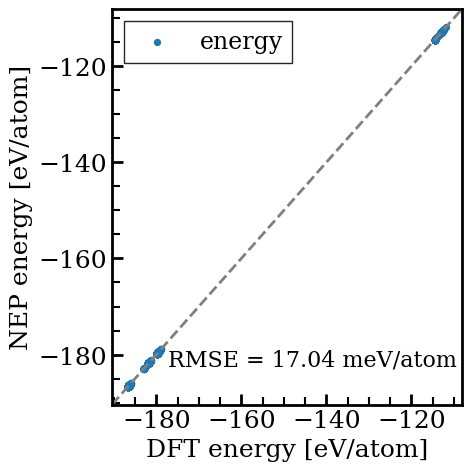

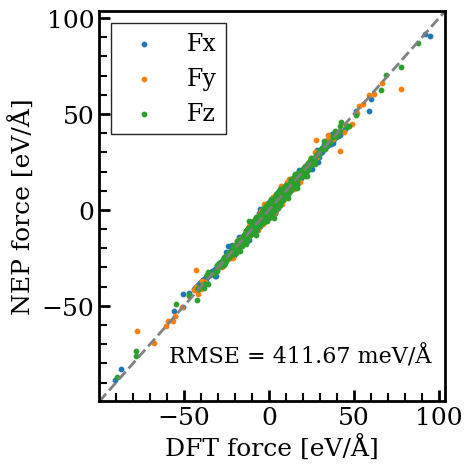

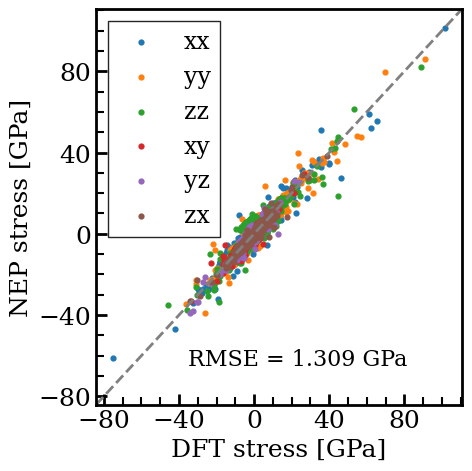

In [40]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

# ============================================================
# JOURNAL-QUALITY GLOBAL SETTINGS
# ============================================================
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Times", "DejaVu Serif"],
    "mathtext.fontset": "stix",

    "font.size": 16,
    "axes.labelsize": 18,
    "axes.titlesize": 18,
    "xtick.labelsize": 18,
    "ytick.labelsize": 18,
    "legend.fontsize": 17,

    "axes.linewidth": 2.0,
    "lines.linewidth": 2.5,
    "lines.markersize": 8,

    "xtick.major.width": 2.0,
    "ytick.major.width": 2.0,
    "xtick.minor.width": 1.5,
    "ytick.minor.width": 1.5,
})

# ============================================================
# AXIS STYLE (ONLY X & Y TICKS — NO TOP/RIGHT)
# ============================================================
def apply_style(ax):
    ax.tick_params(axis='both', which='major',
                   direction='in', length=8, width=2.0,
                   top=False, right=False)
    ax.tick_params(axis='both', which='minor',
                   direction='in', length=6, width=1.5,
                   top=False, right=False)
    ax.minorticks_on()

# ============================================================
# PARITY AXES (NO ASPECT RATIO + SAME TICKS)
# ============================================================
def parity_axes(ax, x, y, nticks=5, pad=0.05):
    vmin = min(x.min(), y.min())
    vmax = max(x.max(), y.max())

    dv = vmax - vmin
    vmin -= pad * dv
    vmax += pad * dv

    ax.set_xlim(vmin, vmax)
    ax.set_ylim(vmin, vmax)

    ax.plot([vmin, vmax], [vmin, vmax],
            '--', color='gray', lw=2)

    ax.xaxis.set_major_locator(MaxNLocator(nbins=nticks))
    ax.yaxis.set_major_locator(MaxNLocator(nbins=nticks))

    # IMPORTANT: no forced aspect ratio
    ax.set_aspect("auto")

# ============================================================
# LOAD DATA
# ============================================================
energy = np.loadtxt("/home/ashwani/conference-paper/train/energy_train.out")
force  = np.loadtxt("/home/ashwani/conference-paper/train/force_train.out")
stress = np.loadtxt("/home/ashwani/conference-paper/train/stress_train.out")

# ============================================================
# ENERGY
# ============================================================
dft_e = energy[:, 0]
nep_e = energy[:, 1]
rmse_e = np.sqrt(np.mean((dft_e - nep_e) ** 2))

# ============================================================
# FORCE
# ============================================================
nep_f = force[:, 0:3]
dft_f = force[:, 3:6]
rmse_f = np.sqrt(np.mean((dft_f - nep_f) ** 2))

labels_f = ["Fx", "Fy", "Fz"]
colors_f = ["tab:blue", "tab:orange", "tab:green"]

# ============================================================
# STRESS
# ============================================================
nep_s = stress[:, 0:6]
dft_s = stress[:, 6:12]

mask = np.all(dft_s > -1e5, axis=1)
nep_s = nep_s[mask]
dft_s = dft_s[mask]

rmse_s = np.sqrt(np.mean((dft_s - nep_s) ** 2))

labels_s = ["xx", "yy", "zz", "xy", "yz", "zx"]
colors_s = ["tab:blue", "tab:orange", "tab:green",
            "tab:red", "tab:purple", "tab:brown"]

# ============================================================
# 1️⃣ ENERGY PARITY
# ============================================================
fig, ax = plt.subplots(figsize=(5, 5))

ax.scatter(dft_e, nep_e, s=18, label="energy")
parity_axes(ax, dft_e, nep_e)
apply_style(ax)

ax.set_xlabel("DFT energy [eV/atom]")
ax.set_ylabel("NEP energy [eV/atom]")

ax.text(0.16, 0.10,
        f"RMSE = {rmse_e*1000:.2f} meV/atom",
        transform=ax.transAxes)

leg = ax.legend(
    loc="upper left",
    frameon=True,
    fancybox=False,
    framealpha=0.85,
)

leg.get_frame().set_edgecolor("black")
leg.get_frame().set_linewidth(1.0)

fig.tight_layout()
fig.savefig("/home/ashwani/conference-paper/figures/parity_energy.pdf", bbox_inches="tight", pad_inches=0)
plt.show()
plt.close(fig)

# ============================================================
# 2️⃣ FORCE PARITY
# ============================================================
fig, ax = plt.subplots(figsize=(5, 5))

for i in range(3):
    ax.scatter(dft_f[:, i], nep_f[:, i],
               s=10, color=colors_f[i], label=labels_f[i])

parity_axes(ax, dft_f.flatten(), nep_f.flatten())
apply_style(ax)

ax.set_xlabel("DFT force [eV/Å]")
ax.set_ylabel("NEP force [eV/Å]")
leg = ax.legend(
    loc="upper left",
    frameon=True,
    fancybox=False,
    framealpha=0.85
)

leg.get_frame().set_edgecolor("black")
leg.get_frame().set_linewidth(1.0)


ax.text(0.20, 0.10,
        f"RMSE = {rmse_f*1000:.2f} meV/Å",
        transform=ax.transAxes)

fig.tight_layout()
fig.savefig("/home/ashwani/conference-paper/figures/parity_force.pdf", bbox_inches="tight", pad_inches=0)
fig.savefig("/home/ashwani/conference-paper/figures/parity_force.png", dpi=300, bbox_inches="tight", pad_inches=0)
plt.show()
plt.close(fig)

# ============================================================
# 3️⃣ STRESS PARITY
# ============================================================
fig, ax = plt.subplots(figsize=(5, 5))

for i in range(6):
    ax.scatter(dft_s[:, i], nep_s[:, i],
               s=12, color=colors_s[i], label=labels_s[i])

parity_axes(ax, dft_s.flatten(), nep_s.flatten())
apply_style(ax)

ax.set_xlabel("DFT stress [GPa]")
ax.set_ylabel("NEP stress [GPa]")
leg = ax.legend(
    loc="upper left",
    frameon=True,
    fancybox=False,
    framealpha=0.85,
    
)

leg.get_frame().set_edgecolor("black")
leg.get_frame().set_linewidth(1.0)


ax.text(0.25, 0.10,
        f"RMSE = {rmse_s:.3f} GPa",
        transform=ax.transAxes)

fig.tight_layout()
fig.savefig("/home/ashwani/conference-paper/figures/parity_stress.pdf", bbox_inches="tight", pad_inches=0)
plt.show()
plt.close(fig)



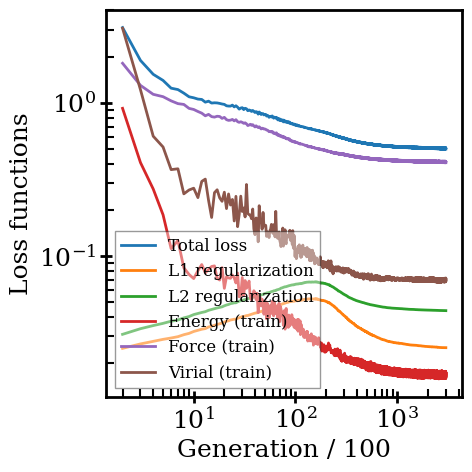

In [43]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# JOURNAL-QUALITY GLOBAL SETTINGS
# ============================================================
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Times", "DejaVu Serif"],
    "mathtext.fontset": "stix",

    "font.size": 16,
    "axes.labelsize": 18,
    "axes.titlesize": 18,
    "xtick.labelsize": 18,
    "ytick.labelsize": 18,
    "legend.fontsize": 12,

    "axes.linewidth": 2.0,
    "lines.linewidth": 2.5,
    "lines.markersize": 8,

    "xtick.major.width": 2.0,
    "ytick.major.width": 2.0,
    "xtick.minor.width": 1.5,
    "ytick.minor.width": 1.5,
})

# ============================================================
# AXIS STYLE
# ============================================================
def apply_style(ax):
    ax.tick_params(axis='both', which='major',
                   direction='inout', length=8, width=2.0)
    ax.tick_params(axis='both', which='minor',
                   direction='in', length=6, width=1.5)
    ax.minorticks_on()

# ============================================================
# LOAD DATA
# ============================================================
data = np.loadtxt("/home/ashwani/conference-paper/train/loss.out", skiprows=1)

step = data[:, 0]
gen  = step / 100.0

total_loss = data[:, 1]
l1_loss    = data[:, 2]
l2_loss    = data[:, 3]

rmse_e_tr = data[:, 4]
rmse_f_tr = data[:, 5]
rmse_v_tr = data[:, 6]

# ============================================================
# PLOT: LOSS EVOLUTION (LEGEND INSIDE)
# ============================================================
fig, ax = plt.subplots(figsize=(5, 5))

ax.plot(gen, total_loss, lw=2, label="Total loss")
ax.plot(gen, l1_loss,    lw=2, label="L1 regularization")
ax.plot(gen, l2_loss,    lw=2, label="L2 regularization")

ax.plot(gen, rmse_e_tr,  lw=2, label="Energy (train)")
ax.plot(gen, rmse_f_tr,  lw=2, label="Force (train)")
ax.plot(gen, rmse_v_tr,  lw=2, label="Virial (train)")

ax.set_xscale("log")
ax.set_yscale("log")

apply_style(ax)

ax.set_xlabel("Generation / 100")
ax.set_ylabel("Loss functions")

# ============================================================
# LEGEND INSIDE (JOURNAL SAFE)
# ============================================================
leg = ax.legend(
    loc="lower left",
    frameon=True,
    fancybox=False,
    framealpha=0.4,
    facecolor="white",
    edgecolor="gray"
)


leg.get_frame().set_edgecolor("black")
leg.get_frame().set_linewidth(1.0)


fig.tight_layout()
fig.savefig("/home/ashwani/conference-paper/figures/loss_evolution.pdf", bbox_inches="tight", pad_inches=0)
plt.show()


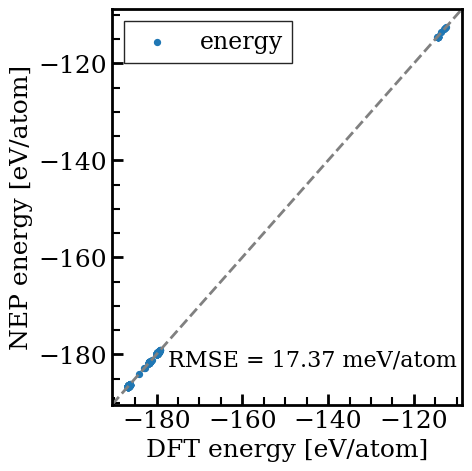

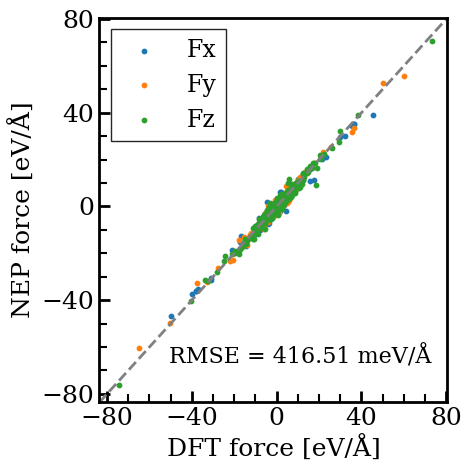

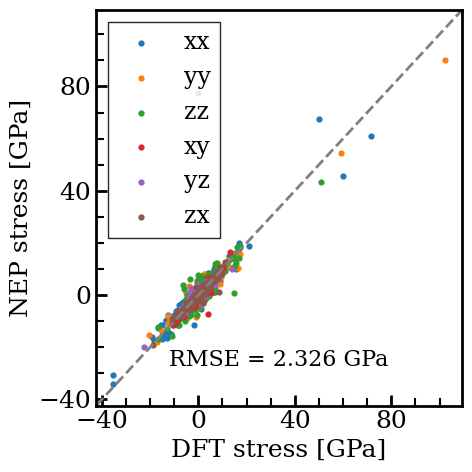

✅ TEST parity plots generated successfully (publication-quality).


In [45]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

# ============================================================
# JOURNAL-QUALITY GLOBAL SETTINGS
# ============================================================
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Times", "DejaVu Serif"],
    "mathtext.fontset": "stix",

    "font.size": 16,
    "axes.labelsize": 18,
    "axes.titlesize": 18,
    "xtick.labelsize": 18,
    "ytick.labelsize": 18,
    "legend.fontsize": 17,

    "axes.linewidth": 2.0,
    "lines.linewidth": 2.5,
    "lines.markersize": 8,

    "xtick.major.width": 2.0,
    "ytick.major.width": 2.0,
    "xtick.minor.width": 1.5,
    "ytick.minor.width": 1.5,
})

# ============================================================
# AXIS STYLE (ONLY X & Y TICKS)
# ============================================================
def apply_style(ax):
    ax.tick_params(axis='both', which='major',
                   direction='in', length=8, width=2.0,
                   top=False, right=False)
    ax.tick_params(axis='both', which='minor',
                   direction='in', length=6, width=1.5,
                   top=False, right=False)
    ax.minorticks_on()

# ============================================================
# PARITY AXES (NO ASPECT RATIO + SAME TICKS)
# ============================================================
def parity_axes(ax, x, y, nticks=5, pad=0.05):
    vmin = min(x.min(), y.min())
    vmax = max(x.max(), y.max())

    dv = vmax - vmin
    vmin -= pad * dv
    vmax += pad * dv

    ax.set_xlim(vmin, vmax)
    ax.set_ylim(vmin, vmax)

    ax.plot([vmin, vmax], [vmin, vmax],
            '--', color='gray', lw=2)

    ax.xaxis.set_major_locator(MaxNLocator(nbins=nticks))
    ax.yaxis.set_major_locator(MaxNLocator(nbins=nticks))

    ax.set_aspect("auto")  # CRITICAL

# ============================================================
# LOAD TEST DATA
# ============================================================
energy = np.loadtxt("/home/ashwani/conference-paper/train/energy_test.out")
force  = np.loadtxt("/home/ashwani/conference-paper//train/force_test.out")
stress = np.loadtxt("/home/ashwani/conference-paper//train/stress_test.out")

# ============================================================
# ENERGY (TEST)
# ============================================================
dft_e = energy[:, 0]
nep_e = energy[:, 1]
rmse_e = np.sqrt(np.mean((dft_e - nep_e) ** 2))

# ============================================================
# FORCE (TEST)
# ============================================================
nep_f = force[:, 0:3]
dft_f = force[:, 3:6]
rmse_f = np.sqrt(np.mean((dft_f - nep_f) ** 2))

labels_f = ["Fx", "Fy", "Fz"]
colors_f = ["tab:blue", "tab:orange", "tab:green"]

# ============================================================
# STRESS (TEST)
# ============================================================
nep_s = stress[:, 0:6]
dft_s = stress[:, 6:12]

mask = np.all(dft_s > -1e5, axis=1)
nep_s = nep_s[mask]
dft_s = dft_s[mask]

rmse_s = np.sqrt(np.mean((dft_s - nep_s) ** 2))

labels_s = ["xx", "yy", "zz", "xy", "yz", "zx"]
colors_s = ["tab:blue", "tab:orange", "tab:green",
            "tab:red", "tab:purple", "tab:brown"]

# ============================================================
# 1️⃣ ENERGY PARITY (TEST)
# ============================================================
fig, ax = plt.subplots(figsize=(5, 5))

ax.scatter(dft_e, nep_e, s=18, label="energy")
parity_axes(ax, dft_e, nep_e)
apply_style(ax)

ax.set_xlabel("DFT energy [eV/atom]")
ax.set_ylabel("NEP energy [eV/atom]")
leg = ax.legend(
    loc="upper left",
    frameon=True,
    fancybox=False,
    framealpha=0.85
)

leg.get_frame().set_edgecolor("black")
leg.get_frame().set_linewidth(1.0)

ax.text(0.16, 0.10,
        f"RMSE = {rmse_e*1000:.2f} meV/atom",
        transform=ax.transAxes)

fig.tight_layout()
fig.savefig("/home/ashwani/conference-paper/figures/parity_energy_test.pdf", bbox_inches="tight", pad_inches=0)
plt.show()
plt.close(fig)

# ============================================================
# 2️⃣ FORCE PARITY (TEST)
# ============================================================
fig, ax = plt.subplots(figsize=(5, 5))

for i in range(3):
    ax.scatter(dft_f[:, i], nep_f[:, i],
               s=10, color=colors_f[i], label=labels_f[i])

parity_axes(ax, dft_f.flatten(), nep_f.flatten())
apply_style(ax)

ax.set_xlabel("DFT force [eV/Å]")
ax.set_ylabel("NEP force [eV/Å]")
leg = ax.legend(
    loc="upper left",
    frameon=True,
    fancybox=False,
    framealpha=0.85
)

leg.get_frame().set_edgecolor("black")
leg.get_frame().set_linewidth(1.0)

ax.text(0.20, 0.10,
        f"RMSE = {rmse_f*1000:.2f} meV/Å",
        transform=ax.transAxes)

fig.tight_layout()
fig.savefig("/home/ashwani/conference-paper/figures/parity_force_test.pdf", bbox_inches="tight", pad_inches=0)
plt.show()
plt.close(fig)

# ============================================================
# 3️⃣ STRESS PARITY (TEST)
# ============================================================
fig, ax = plt.subplots(figsize=(5, 5))

for i in range(6):
    ax.scatter(dft_s[:, i], nep_s[:, i],
               s=12, color=colors_s[i], label=labels_s[i])

parity_axes(ax, dft_s.flatten(), nep_s.flatten())
apply_style(ax)

ax.set_xlabel("DFT stress [GPa]")
ax.set_ylabel("NEP stress [GPa]")

leg = ax.legend(
    loc="upper left",
    frameon=True,
    fancybox=False,
    framealpha=0.85
)

leg.get_frame().set_edgecolor("black")
leg.get_frame().set_linewidth(1.0)

ax.text(0.20, 0.10,
        f"RMSE = {rmse_s:.3f} GPa",
        transform=ax.transAxes)

fig.tight_layout()
fig.savefig("/home/ashwani/conference-paper/figures/parity_stress_test.pdf", bbox_inches="tight", pad_inches=0)
plt.show()
plt.close(fig)

print("✅ TEST parity plots generated successfully (publication-quality).")



Run 1: Lz0 = 93.5319, Residual Pzz0 = -0.105475


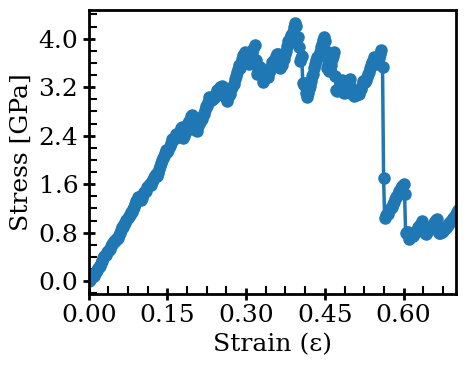

Saved: /home/ashwani/conference-paper/figures/Pzz_vs_Strain_run_1_residual_removed.pdf
Run 2: Lz0 = 82.8781, Residual Pzz0 = 0.034181


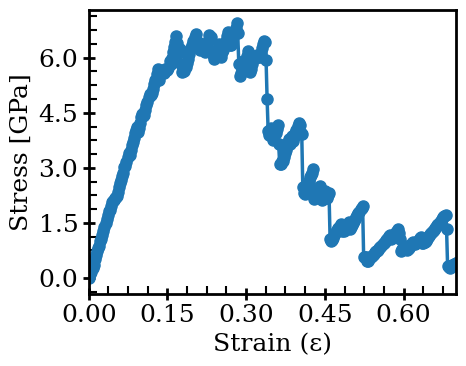

Saved: /home/ashwani/conference-paper/figures/Pzz_vs_Strain_run_2_residual_removed.pdf
Run 3: Lz0 = 70.9410, Residual Pzz0 = -0.252405


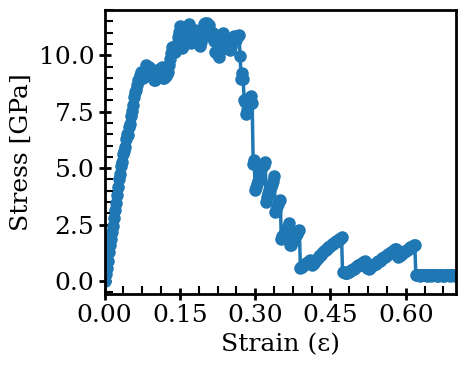

Saved: /home/ashwani/conference-paper/figures/Pzz_vs_Strain_run_3_residual_removed.pdf


In [21]:
import os
import re
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

# ============================================================
# JOURNAL-QUALITY GLOBAL SETTINGS
# ============================================================
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Times", "DejaVu Serif"],
    "mathtext.fontset": "stix",
    "font.size": 18,
    "axes.labelsize": 18,
    "axes.titlesize": 18,
    "xtick.labelsize": 18,
    "ytick.labelsize": 18,
    "legend.fontsize": 15,
    "axes.linewidth": 2.0,
    "lines.linewidth": 2.5,
})

def apply_style(ax):
    ax.tick_params(axis='both', which='major', direction='inout', length=8, width=2)
    ax.tick_params(axis='both', which='minor', direction='in', length=6, width=1.5)
    ax.minorticks_on()
    ax.xaxis.set_major_locator(MaxNLocator(6))
    ax.yaxis.set_major_locator(MaxNLocator(6))

# ============================================================
# INPUT
# ============================================================
base_dir = "/home/ashwani/conference-paper/tensile"
folders = ["1", "2", "3"]
data_file_name = "Strain_Stress.dat"

save_dir = "/home/ashwani/conference-paper/figures"
os.makedirs(save_dir, exist_ok=True)

# ============================================================
# LOOP OVER RUNS (SEPARATE FIGURES, RESIDUAL STRESS REMOVED)
# ============================================================
for f in folders:
    data_file = os.path.join(base_dir, f, data_file_name)

    if not os.path.exists(data_file):
        print("❌ File not found:", data_file)
        continue

    lz_list = []
    pzz_list = []

    with open(data_file, "r") as fp:
        for line in fp:
            lz  = re.search(r"lz:\s*([-\d\.Ee+]+)", line)
            pzz = re.search(r"Pzz:\s*([-\d\.Ee+]+)", line)

            if lz and pzz:
                lz_list.append(float(lz.group(1)))
                pzz_list.append(float(pzz.group(1)))

    if len(lz_list) == 0:
        print("⚠ No data in:", data_file)
        continue

    # ---------------- STRAIN ----------------
    Lz0 = lz_list[0]
    strain = [(lz - Lz0) / Lz0 for lz in lz_list]

    # ---------------- RESIDUAL STRESS REMOVAL ----------------
    Pzz0 = pzz_list[0]
    pzz_corr = [p - Pzz0 for p in pzz_list]

    print(f"Run {f}: Lz0 = {Lz0:.4f}, Residual Pzz0 = {Pzz0:.6f}")

    # ---------------- FIGURE ----------------
    fig, ax = plt.subplots(figsize=(5, 4))

    ax.plot(strain, pzz_corr, marker='o')
    ax.set_xlim([0, 0.7])
    ax.set_xlabel("Strain (ε)")
    ax.set_ylabel("Stress [GPa]")
 

    apply_style(ax)
    plt.tight_layout()

    save_name = os.path.join(save_dir, f"Pzz_vs_Strain_run_{f}_residual_removed.pdf")
    plt.savefig(save_name, bbox_inches="tight", pad_inches=0)
    plt.show()
    plt.close()

    print("Saved:", save_name)



density = 0.80:
  Young’s Modulus (E) = 5.53 GPa
  R² = 0.99008
  σ_max = 3.91 GPa at ε = 0.638


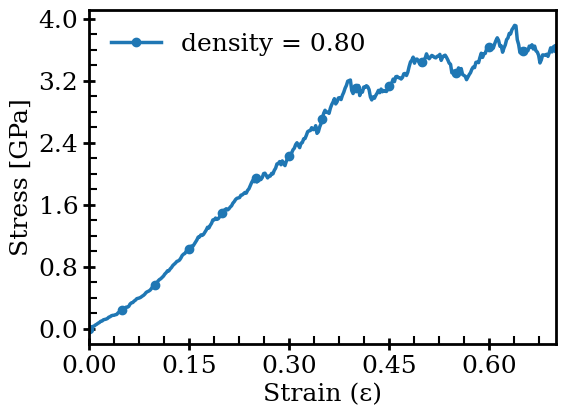

📈 Saved individual plot: /home/ashwani/conference-paper/figures/Pzz_vs_Strain_density = 0.80.pdf

density = 1.00:
  Young’s Modulus (E) = 25.35 GPa
  R² = 0.98707
  σ_max = 4.00 GPa at ε = 0.402


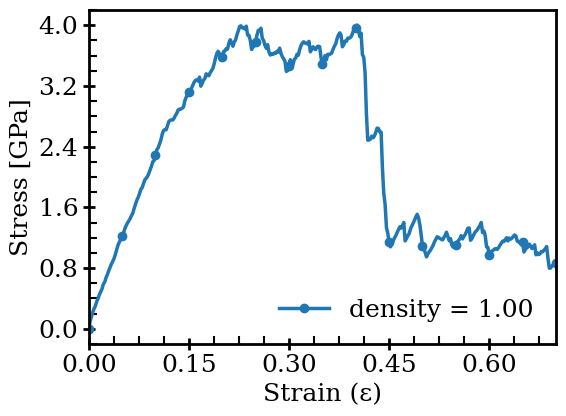

📈 Saved individual plot: /home/ashwani/conference-paper/figures/Pzz_vs_Strain_density = 1.00.pdf

density = 1.30:
  Young’s Modulus (E) = 51.71 GPa
  R² = 0.99770
  σ_max = 8.51 GPa at ε = 0.330


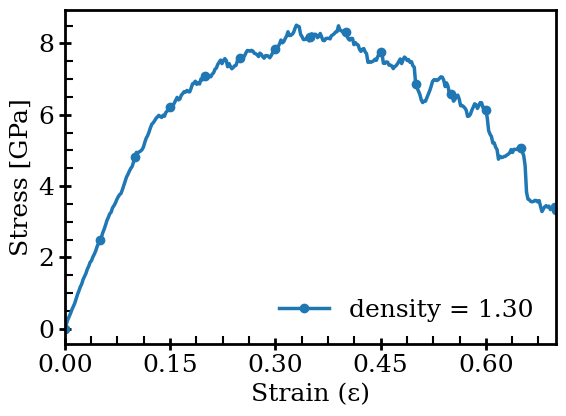

📈 Saved individual plot: /home/ashwani/conference-paper/figures/Pzz_vs_Strain_density = 1.30.pdf

density = 1.60:
  Young’s Modulus (E) = 74.67 GPa
  R² = 0.99323
  σ_max = 7.71 GPa at ε = 0.434


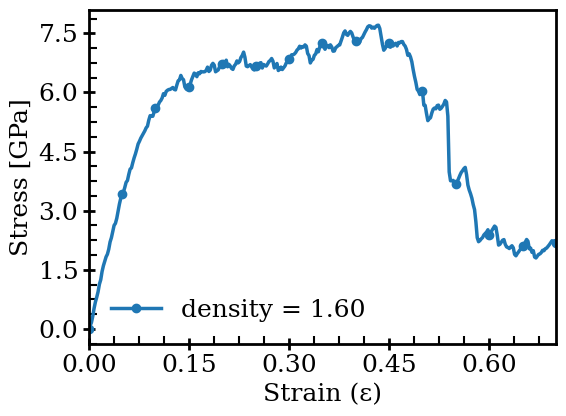

📈 Saved individual plot: /home/ashwani/conference-paper/figures/Pzz_vs_Strain_density = 1.60.pdf

density = 2.00:
  Young’s Modulus (E) = 90.62 GPa
  R² = 0.98338
  σ_max = 12.54 GPa at ε = 0.120


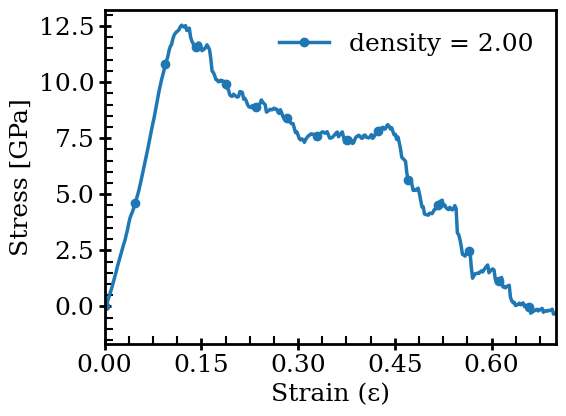

📈 Saved individual plot: /home/ashwani/conference-paper/figures/Pzz_vs_Strain_density = 2.00.pdf

density = 2.30:
  Young’s Modulus (E) = 104.63 GPa
  R² = 0.99714
  σ_max = 10.75 GPa at ε = 0.126


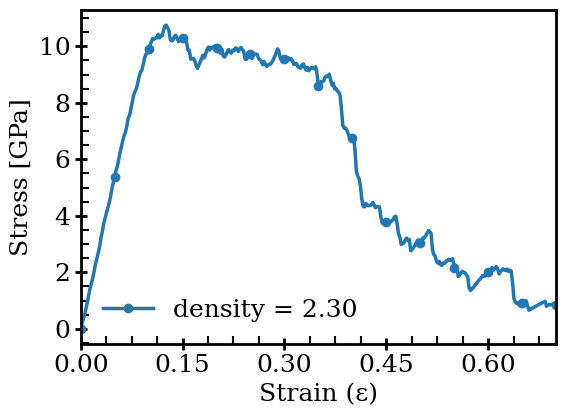

📈 Saved individual plot: /home/ashwani/conference-paper/figures/Pzz_vs_Strain_density = 2.30.pdf

✅ Combined plot saved: /home/ashwani/conference-paper/figures/All_Density_Stress_Strain.pdf

🎯 All runs completed successfully.


In [9]:
#!/usr/bin/env python3
import os
import re
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

# ============================================================
# JOURNAL-QUALITY PLOTTING SETTINGS
# ============================================================
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Times", "DejaVu Serif"],
    "mathtext.fontset": "stix",
    "font.size": 18,
    "axes.labelsize": 18,
    "axes.titlesize": 18,
    "xtick.labelsize": 18,
    "ytick.labelsize": 18,
    "axes.linewidth": 2.0,
    "lines.linewidth": 2.5,
})

def apply_style(ax):
    ax.tick_params(axis='both', which='major', direction='inout', length=8, width=2)
    ax.tick_params(axis='both', which='minor', direction='in', length=6, width=1.5)
    ax.minorticks_on()
    ax.xaxis.set_major_locator(MaxNLocator(6))
    ax.yaxis.set_major_locator(MaxNLocator(6))

# ============================================================
# PATHS AND INPUT FILES
# ============================================================
base_dir = "/home/ashwani/conference-paper/tensile"
save_dir = "/home/ashwani/conference-paper/figures"
os.makedirs(save_dir, exist_ok=True)

density_labels = {
    1: "density = 0.80",
    2: "density = 1.00",
    3: "density = 1.30",
    4: "density = 1.60",
    5: "density = 2.00",
    6: "density = 2.30"
}

elastic_limit = 0.02  # strain range for linear (elastic) region

# ============================================================
# LOOP OVER ALL FILES
# ============================================================
all_data = {}

for i in range(1, 7):
    data_file = os.path.join(base_dir, f"Strain_Stress_{i}.dat")
    label = density_labels[i]

    if not os.path.exists(data_file):
        print(f"❌ File not found: {data_file}")
        continue

    lz_list, pzz_list = [], []
    with open(data_file, "r") as f:
        for line in f:
            lz = re.search(r"lz:\s*([-\d\.Ee+]+)", line)
            pzz = re.search(r"Pzz:\s*([-\d\.Ee+]+)", line)
            if lz and pzz:
                lz_list.append(float(lz.group(1)))
                pzz_list.append(float(pzz.group(1)))

    if not lz_list:
        print(f"⚠️ No valid data in {label}")
        continue

    # ---------------- COMPUTE STRAIN/STRESS ----------------
    lz_arr = np.array(lz_list)
    strain = (lz_arr - lz_arr[0]) / lz_arr[0]
    stress = np.array(pzz_list) - pzz_list[0]

    # ---------------- FIT LINEAR ELASTIC REGION (HIDDEN) ----------------
    mask = strain <= elastic_limit
    x, y = strain[mask], stress[mask]
    coef = np.polyfit(x, y, 1)
    E = coef[0]

    # ---------------- PRINT RESULTS ONLY ----------------
    ss_res = np.sum((y - np.polyval(coef, x))**2)
    ss_tot = np.sum((y - np.mean(y))**2)
    R2 = 1 - ss_res / ss_tot

    max_stress = np.max(stress)
    max_strain = strain[np.argmax(stress)]

    print(f"\n{label}:")
    print(f"  Young’s Modulus (E) = {E:.2f} GPa")
    print(f"  R² = {R2:.5f}")
    print(f"  σ_max = {max_stress:.2f} GPa at ε = {max_strain:.3f}")

    # ---------------- INDIVIDUAL PLOT ----------------
    fig, ax = plt.subplots(figsize=(6, 4.5))
    mark_step = max(len(strain)//40, 1)

    ax.plot(strain, stress, color="#1f77b4", label=label, marker='o', markevery=mark_step)

    ax.set_xlim([0, 0.7])
    ax.set_xlabel("Strain (ε)")
    ax.set_ylabel("Stress [GPa]")
    ax.legend(frameon=False, loc="best")
 

    apply_style(ax)
    plt.tight_layout()

    out_file = os.path.join(save_dir, f"Pzz_vs_Strain_{label}.pdf")
    plt.savefig(out_file, bbox_inches="tight", pad_inches=0)
    plt.show()
    plt.close()

    print(f"📈 Saved individual plot: {out_file}")

    all_data[label] = (strain, stress)

# ============================================================
# COMBINED PLOT — ALL DENSITIES TOGETHER
# ============================================================
plt.figure(figsize=(7.5, 6))
ax = plt.gca()

colors = plt.cm.tab10(np.linspace(0, 1, len(all_data)))

for (label, (strain, stress)), color in zip(all_data.items(), colors):
    mark_step = max(len(strain)//40, 1)
    ax.plot(
        strain, stress,
        markevery=mark_step,
        label=label,
        color=color,
        linewidth=2.5
    )

ax.set_xlim([0, 0.7])
ax.set_xlabel("Strain (ε)")
ax.set_ylabel("Stress [GPa]")
ax.set_title("Stress–Strain Curves for Various Densities")

apply_style(ax)
plt.tight_layout(rect=[0, 0, 0.8, 1])

ax.legend(
    frameon=False,
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    title="Densities",
    fontsize=15,
    title_fontsize=15
)

combined_file = os.path.join(save_dir, "All_Density_Stress_Strain.pdf")
plt.savefig(combined_file, bbox_inches="tight", pad_inches=0.1)
# plt.show()
plt.close()

print(f"\n✅ Combined plot saved: {combined_file}")
print("\n🎯 All runs completed successfully.")


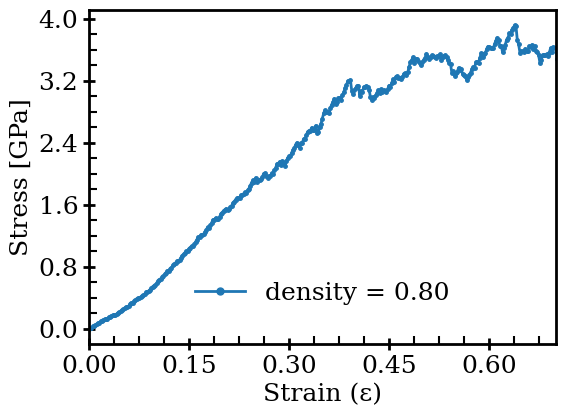

📈 Saved: /home/ashwani/conference-paper/figures/Pzz_vs_Strain_density_0.80.pdf


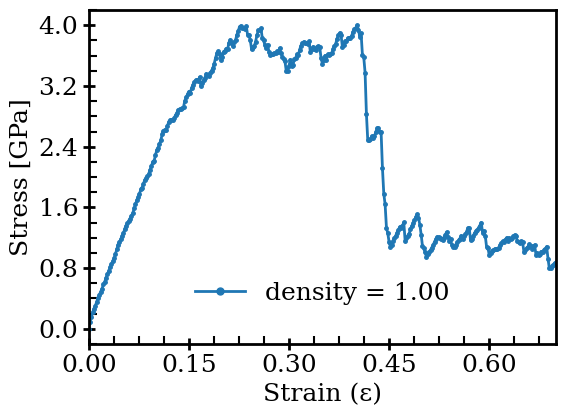

📈 Saved: /home/ashwani/conference-paper/figures/Pzz_vs_Strain_density_1.00.pdf


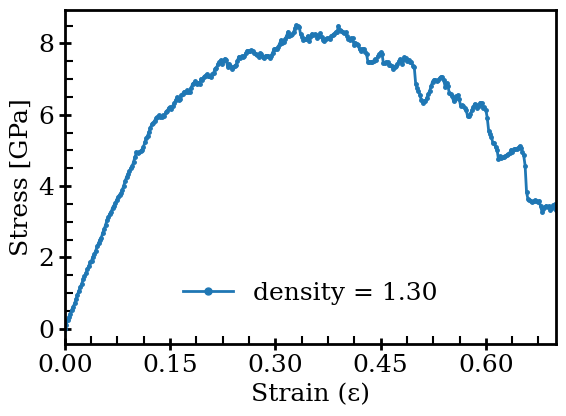

📈 Saved: /home/ashwani/conference-paper/figures/Pzz_vs_Strain_density_1.30.pdf


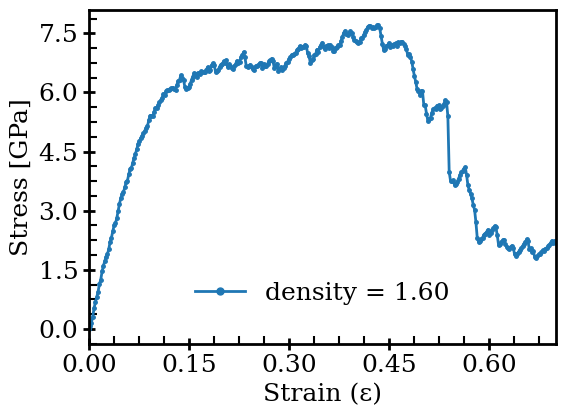

📈 Saved: /home/ashwani/conference-paper/figures/Pzz_vs_Strain_density_1.60.pdf


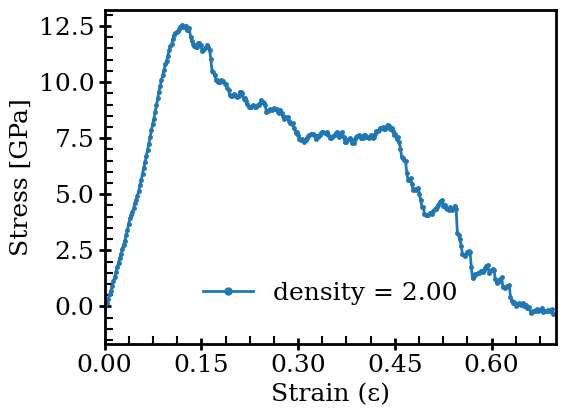

📈 Saved: /home/ashwani/conference-paper/figures/Pzz_vs_Strain_density_2.00.pdf


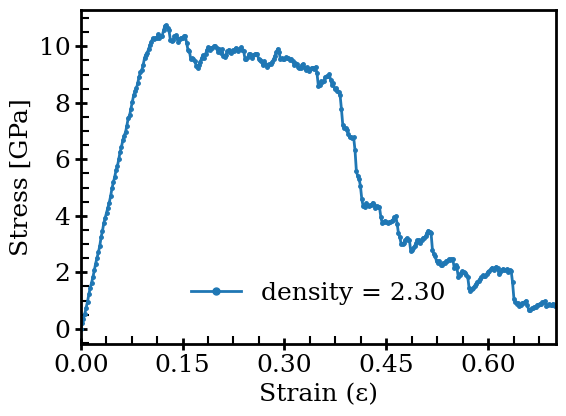

📈 Saved: /home/ashwani/conference-paper/figures/Pzz_vs_Strain_density_2.30.pdf


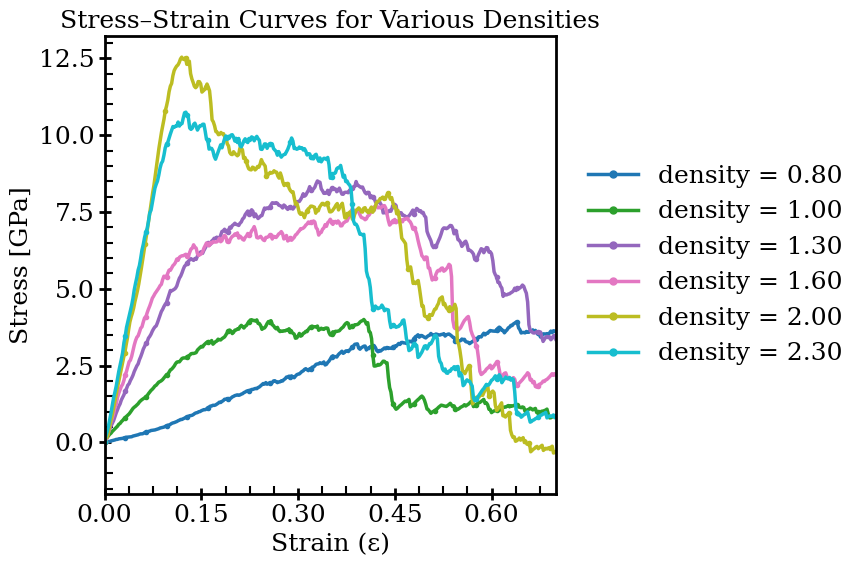


✅ ALL FIGURES SAVED WITH CORRECT LEGEND STYLE


In [14]:
#!/usr/bin/env python3
import os
import re
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
from matplotlib.lines import Line2D

# ============================================================
# JOURNAL-QUALITY PLOTTING SETTINGS
# ============================================================
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Times", "DejaVu Serif"],
    "mathtext.fontset": "stix",
    "font.size": 18,
    "axes.labelsize": 18,
    "axes.titlesize": 18,
    "xtick.labelsize": 18,
    "ytick.labelsize": 18,
    "axes.linewidth": 2.0,
    "lines.linewidth": 2.5,
})

def apply_style(ax):
    ax.tick_params(axis='both', which='major', direction='inout', length=8, width=2)
    ax.tick_params(axis='both', which='minor', direction='in', length=6, width=1.5)
    ax.minorticks_on()
    ax.xaxis.set_major_locator(MaxNLocator(6))
    ax.yaxis.set_major_locator(MaxNLocator(6))

# ============================================================
# PATHS
# ============================================================
base_dir = "/home/ashwani/conference-paper/tensile"
save_dir = "/home/ashwani/conference-paper/figures"
os.makedirs(save_dir, exist_ok=True)

density_labels = {
    1: "density = 0.80",
    2: "density = 1.00",
    3: "density = 1.30",
    4: "density = 1.60",
    5: "density = 2.00",
    6: "density = 2.30"
}

elastic_limit = 0.02

# ============================================================
# READ ALL DATA
# ============================================================
all_data = {}

for i in range(1, 7):
    path = os.path.join(base_dir, f"Strain_Stress_{i}.dat")
    label = density_labels[i]

    if not os.path.exists(path):
        print(f"❌ Missing file: {path}")
        continue

    lz, pzz = [], []
    with open(path) as f:
        for line in f:
            l = re.search(r"lz:\s*([-\d\.Ee+]+)", line)
            p = re.search(r"Pzz:\s*([-\d\.Ee+]+)", line)
            if l and p:
                lz.append(float(l.group(1)))
                pzz.append(float(p.group(1)))

    if not lz:
        continue

    lz = np.array(lz)
    strain = (lz - lz[0]) / lz[0]
    stress = np.array(pzz) - pzz[0]

    all_data[label] = (strain, stress)

    # ========================================================
    # INDIVIDUAL FIGURE: LINE + DENSE POINTS + CUSTOM LEGEND
    # ========================================================
    fig, ax = plt.subplots(figsize=(6, 4.5))

    # line
    ax.plot(strain, stress, color="#1f77b4", linewidth=2.0)

    # dense points
    ax.plot(strain, stress, linestyle='None',
            marker='o', markersize=2.5, color="#1f77b4")

    # custom legend handle (line + marker)
    legend_handle = Line2D(
        [0], [0],
        color="#1f77b4",
        linewidth=2.0,
        marker='o',
        markersize=5,
        label=label
    )

    ax.legend(
        handles=[legend_handle],
        frameon=False,
        loc="lower center",
        bbox_to_anchor=(0.5, 0.05)
    )

    ax.set_xlim(0, 0.7)
    ax.set_xlabel("Strain (ε)")
    ax.set_ylabel("Stress [GPa]")

    apply_style(ax)
    plt.tight_layout()

    out = os.path.join(save_dir, f"Pzz_vs_Strain_{label.replace(' ', '').replace('=', '_')}.pdf")
    plt.savefig(out, bbox_inches="tight", pad_inches=0)
    plt.show()
    plt.close()

    print(f"📈 Saved: {out}")

# ============================================================
# COMBINED FIGURE: ALL DENSITIES (same legend style)
# ============================================================
fig, ax = plt.subplots(figsize=(7.5, 6))
colors = plt.cm.tab10(np.linspace(0, 1, len(all_data)))

legend_handles = []

for (label, (strain, stress)), c in zip(all_data.items(), colors):
    step = max(len(strain)//60, 1)

    ax.plot(strain, stress, linewidth=2.5, color=c)
    ax.plot(strain, stress, linestyle='None',
            marker='o', markersize=3, markevery=step, color=c)

    legend_handles.append(
        Line2D([0], [0], color=c, linewidth=2.5,
               marker='o', markersize=5, label=label)
    )

ax.set_xlim(0, 0.7)
ax.set_xlabel("Strain (ε)")
ax.set_ylabel("Stress [GPa]")
ax.set_title("Stress–Strain Curves for Various Densities")

apply_style(ax)
plt.tight_layout(rect=[0, 0, 0.8, 1])

ax.legend(
    handles=legend_handles,
    frameon=False,
    loc="center left",
    bbox_to_anchor=(1.02, 0.5)
)

out = os.path.join(save_dir, "All_Density_Stress_Strain.pdf")
plt.savefig(out, bbox_inches="tight", pad_inches=0.1)
plt.show()
plt.close()

print("\n✅ ALL FIGURES SAVED WITH CORRECT LEGEND STYLE")


🔍 Checking RDF data files...

✅ Found a-BN → rdf_0GPa_300K_NVT_a-BN.dat (11.7 KB)
✅ Found c-BN → rdf_0GPa_300K_NVT_c-BN.dat (10.9 KB)
✅ Found h-BN → rdf_0GPa_300K_NVT_h-BN.dat (9.8 KB)

✅ All RDF files are present. Proceeding to plot...


📊 a-BN — RDF Peaks up to 4 Å:
   ↳ Peak at r = 1.46 Å, g(r) = 8.10
   ↳ Peak at r = 2.53 Å, g(r) = 2.36
   ↳ Peak at r = 3.81 Å, g(r) = 1.23


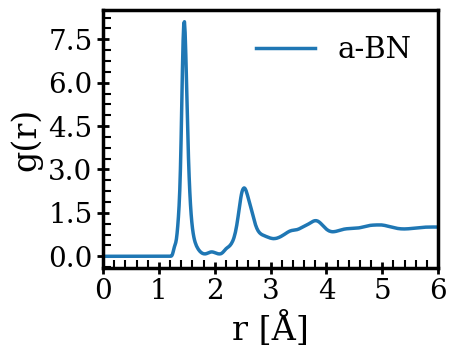

📈 Saved RDF plot: /home/ashwani/home_computer/conference-paper/figures/rdf/rdf_a-BN.pdf


📊 c-BN — RDF Peaks up to 4 Å:
   ↳ Peak at r = 1.57 Å, g(r) = 8.13
   ↳ Peak at r = 2.56 Å, g(r) = 8.05
   ↳ Peak at r = 3.01 Å, g(r) = 5.41
   ↳ Peak at r = 3.63 Å, g(r) = 1.78
   ↳ Peak at r = 3.95 Å, g(r) = 3.13


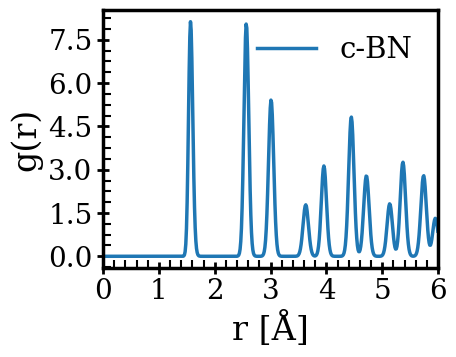

📈 Saved RDF plot: /home/ashwani/home_computer/conference-paper/figures/rdf/rdf_c-BN.pdf


📊 h-BN — RDF Peaks up to 4 Å:
   ↳ Peak at r = 1.45 Å, g(r) = 88.85
   ↳ Peak at r = 2.50 Å, g(r) = 44.24
   ↳ Peak at r = 2.89 Å, g(r) = 14.50
   ↳ Peak at r = 3.82 Å, g(r) = 17.32


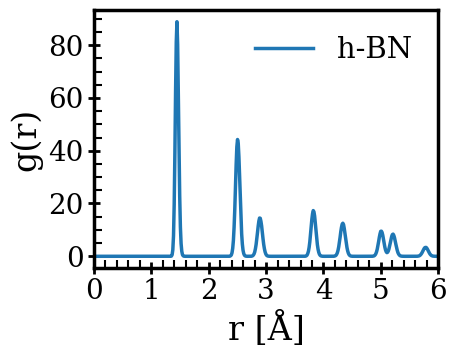

📈 Saved RDF plot: /home/ashwani/home_computer/conference-paper/figures/rdf/rdf_h-BN.pdf

✅ All RDF plots generated successfully!



In [6]:
#!/usr/bin/env python3
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
from scipy.signal import find_peaks
import os
import sys

# ============================================================
# PATHS AND SETUP
# ============================================================
base_dir = "/home/ashwani/home_computer/conference-paper/rdf"
save_dir = "/home/ashwani/home_computer/conference-paper/figures/rdf"
os.makedirs(save_dir, exist_ok=True)

files = {
    "a-BN": "rdf_0GPa_300K_NVT_a-BN.dat",
    "c-BN": "rdf_0GPa_300K_NVT_c-BN.dat",
    "h-BN": "rdf_0GPa_300K_NVT_h-BN.dat",
}

# ============================================================
# JOURNAL-QUALITY PLOTTING SETTINGS
# ============================================================
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Times", "DejaVu Serif"],
    "mathtext.fontset": "stix",
    "font.size": 21,
    "axes.labelsize": 24,
    "axes.titlesize": 24,
    "xtick.labelsize": 20,
    "ytick.labelsize": 20,
    "axes.linewidth": 2.5,
    "lines.linewidth": 2.5,
})

def apply_style(ax):
    ax.tick_params(axis='both', which='major', direction='inout', length=8, width=2)
    ax.tick_params(axis='both', which='minor', direction='in', length=6, width=1.5)
    ax.minorticks_on()
    ax.xaxis.set_major_locator(MaxNLocator(6))
    ax.yaxis.set_major_locator(MaxNLocator(6))

# ============================================================
# CHECK FILE EXISTENCE
# ============================================================
print("🔍 Checking RDF data files...\n")

missing_files = []
for label, filename in files.items():
    file_path = os.path.join(base_dir, filename)
    if not os.path.exists(file_path):
        print(f"❌ Missing file for {label}: {file_path}")
        missing_files.append(file_path)
    else:
        size_kb = os.path.getsize(file_path) / 1024
        print(f"✅ Found {label} → {filename} ({size_kb:.1f} KB)")

if missing_files:
    print("\n⚠️ Some RDF files are missing. Please add them before proceeding.")
    sys.exit(1)

print("\n✅ All RDF files are present. Proceeding to plot...\n")

# ============================================================
# PROCESS & PLOT RDF FILES
# ============================================================
for label, filename in files.items():
    file_path = os.path.join(base_dir, filename)
    try:
        # Read numeric data, skip headers
        raw_data = []
        with open(file_path, "r") as f:
            for line in f:
                if line.strip().startswith("#") or len(line.strip()) == 0:
                    continue
                parts = line.split()
                if len(parts) >= 3:
                    try:
                        raw_data.append([float(p) for p in parts])
                    except ValueError:
                        continue

        data = np.array(raw_data)
        if data.shape[0] == 0:
            raise ValueError("No valid numeric data found.")

        r = data[:, 1]  # Å
        g = data[:, 2]  # g(r)

        # Find peaks up to 4 Å (for printing only)
        peaks, _ = find_peaks(g, height=0.5)
        r_peaks = r[peaks][r[peaks] <= 4.0]
        g_peaks = g[peaks][r[peaks] <= 4.0]

        print(f"\n📊 {label} — RDF Peaks up to 4 Å:")
        if len(r_peaks) == 0:
            print("   ⚠️ No peaks found below 4 Å")
        else:
            for rp, gp in zip(r_peaks, g_peaks):
                print(f"   ↳ Peak at r = {rp:.2f} Å, g(r) = {gp:.2f}")

        # --- PLOT ---
        fig, ax = plt.subplots(figsize=(5, 4))
        ax.plot(r, g, label=label)
        ax.set_xlim([0, 6])
        ax.set_xlabel("r [Å]")
        ax.set_ylabel("g(r)")
    
        ax.legend(frameon=False)
        apply_style(ax)
        plt.tight_layout()

        save_path = os.path.join(save_dir, f"rdf_{label}.pdf")
        plt.savefig(save_path, bbox_inches="tight", pad_inches=0.05)
        plt.show()
        plt.close()

        print(f"📈 Saved RDF plot: {save_path}\n")

    except Exception as e:
        print(f"❌ Error processing {label}: {e}\n")

print("✅ All RDF plots generated successfully!\n")
